# Permutation Importance vs SHAP for Random Forests
## Which Explanation Should You Trust?

**Author:** Adil Nawaz | | **Date:** March 2026

---

## Learning Objectives

By the end of this tutorial you will be able to:

1. **Explain** how Random Forest Gini importance works and identify its known biases
2. **Implement** permutation importance and interpret the results with confidence intervals
3. **Apply** SHAP (SHapley Additive exPlanations) to explain model predictions at both global and local levels
4. **Compare** three feature importance methods and assess when each is most appropriate
5. **Critically evaluate** why different explanation methods can disagree on the same model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
import shap
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Colour-blind friendly palette
CB_PALETTE = ['#0072B2', '#D55E00', '#009E73', '#F0E442', '#CC79A7', '#56B4E9', '#E69F00']
sns.set_style('whitegrid')
sns.set_palette(CB_PALETTE)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

FIG_DIR = '../figures'
import os; os.makedirs(FIG_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Why Should We Care About Feature Importance?

Imagine you build a model that predicts whether someone earns above \$50K. It achieves 85% accuracy — great! But your manager asks: *"Which factors drive that prediction?"*

Accuracy alone is not enough. We need **model interpretability** — the ability to explain *why* a model makes its predictions. This matters for:

- **Trust:** Stakeholders won't adopt a model they can't understand
- **Debugging:** Unexpected important features often signal data leakage or bugs
- **Fairness:** We must check whether protected attributes (race, gender) unduly influence predictions
- **Domain insight:** Feature importance can reveal patterns experts hadn't considered

In this tutorial, we compare **three methods** for measuring feature importance in Random Forests, showing that they sometimes agree — and sometimes **dramatically disagree**.

In [2]:
# Load the Adult Income dataset
from sklearn.datasets import fetch_openml

print("Loading Adult Income dataset...")
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
df = adult.frame.copy()

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['class'].value_counts()}")
print(f"\nFeature types:\n{df.dtypes}")

Loading Adult Income dataset...
Dataset shape: (48842, 15)
Target distribution:
class
<=50K    37155
>50K     11687
Name: count, dtype: int64

Feature types:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object


## 2. Dataset: Adult Income Census

The **Adult Income dataset** (also called the Census Income dataset) contains 48,842 records extracted from the 1994 US Census. Each record has 14 features describing a person's demographics and employment, and a binary target: whether their annual income exceeds \$50,000.

**Why this dataset?** It has a mix of numerical features (age, hours-per-week, capital-gain) and categorical features (workclass, education, occupation). This mix is ideal for our experiment because different importance methods handle categorical variables differently — which is exactly where disagreements emerge.

In [3]:
# Preprocessing
# Drop rows with missing values (marked as '?' in original)
df = df.replace('?', np.nan).dropna()
print(f"After dropping missing values: {df.shape}")

# Separate features and target
target_col = 'class'
y_raw = df[target_col]
X_raw = df.drop(columns=[target_col])

# Encode target: >50K = 1, <=50K = 0
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)
print(f"Target classes: {le_target.classes_}")
print(f"Class balance: {np.bincount(y)} (0: <=50K, 1: >50K)")

# Encode categorical features using LabelEncoder (for tree models this is sufficient)
feature_names = list(X_raw.columns)
feature_names_arr = np.array(feature_names)
cat_cols = X_raw.select_dtypes(include=['category', 'object']).columns.tolist()
num_cols = X_raw.select_dtypes(include=['number']).columns.tolist()
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features ({len(num_cols)}): {num_cols}")

X_encoded = X_raw.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

X = X_encoded.values
print(f"\nFinal feature matrix shape: {X.shape}")

After dropping missing values: (45222, 15)
Target classes: ['<=50K' '>50K']
Class balance: [34014 11208] (0: <=50K, 1: >50K)

Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Final feature matrix shape: (45222, 14)


In [4]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test class balance:  {np.bincount(y_test)}")

Training set: 36177 samples
Test set:     9045 samples
Train class balance: [27211  8966]
Test class balance:  [6803 2242]


In [5]:
# Train a Random Forest classifier
# We use 200 trees for stable importance estimates
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=le_target.classes_)}")

Test Accuracy: 0.8604

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      6803
        >50K       0.78      0.61      0.68      2242

    accuracy                           0.86      9045
   macro avg       0.83      0.78      0.80      9045
weighted avg       0.85      0.86      0.85      9045



## 3. Method 1: Gini Importance (Built-in)

Random Forest's **built-in feature importance** (also called *Mean Decrease in Impurity* or *Gini importance*) works by measuring how much each feature reduces the Gini impurity across all trees:

1. For every split in every tree, record how much the Gini impurity decreased
2. Sum these decreases for each feature across all trees
3. Normalise so they sum to 1

**Strengths:** Fast (computed during training), no extra computation needed.

**Known weakness:** Gini importance is **biased toward high-cardinality features**. A categorical feature with many unique values (like `native-country` with 41 categories) gets more opportunities to split, inflating its apparent importance even if it has no real predictive power. This is a well-documented bias (Strobl et al., 2007).

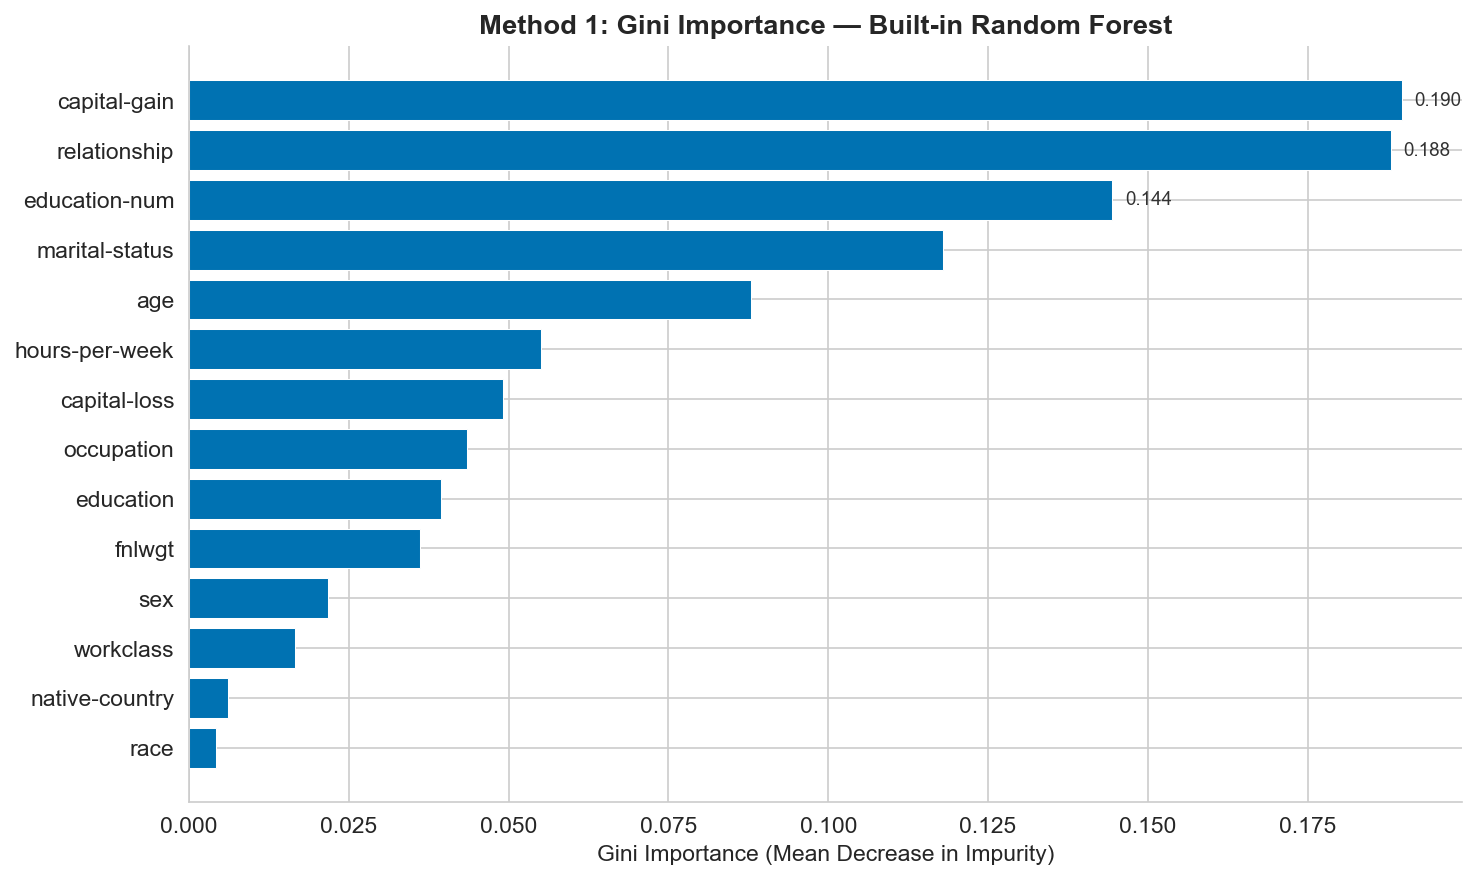

Top 5 features by Gini importance:
  1. capital-gain: 0.1897
  2. relationship: 0.1880
  3. education-num: 0.1444
  4. marital-status: 0.1180
  5. age: 0.0880


In [6]:
# Method 1: Gini (impurity-based) importance
gini_imp = rf.feature_importances_
gini_order = np.argsort(gini_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(feature_names))
sorted_imp = gini_imp[gini_order]
sorted_names = feature_names_arr[gini_order].tolist()

bars = ax.barh(y_pos, sorted_imp, color=CB_PALETTE[0], edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel('Gini Importance (Mean Decrease in Impurity)')
ax.set_title('Method 1: Gini Importance — Built-in Random Forest', fontweight='bold')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Annotate top 3
for i in range(3):
    ax.text(sorted_imp[i] + 0.002, i, f'{sorted_imp[i]:.3f}', va='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/gini_importance.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Top 5 features by Gini importance:")
for i in range(5):
    print(f"  {i+1}. {sorted_names[i]}: {sorted_imp[i]:.4f}")

## 4. Method 2: Permutation Importance

Permutation importance measures how much the model's accuracy **drops** when a single feature's values are randomly shuffled:

1. Record the baseline accuracy on the test set
2. For each feature: shuffle its column, re-score the model, record the accuracy drop
3. Repeat multiple times to get confidence intervals

**Key insight:** If shuffling a feature barely changes accuracy, that feature isn't important for predictions — regardless of what the model's internals suggest.

**Advantages over Gini:**
- Model-agnostic (works with any classifier)
- Not biased by feature cardinality
- Measured on held-out test data, so it reflects generalisation importance

**Limitation:** Correlated features can mask each other's importance. If features A and B are highly correlated, shuffling A alone may not hurt accuracy because B still carries the signal.

Computing permutation importance (10 repeats)...


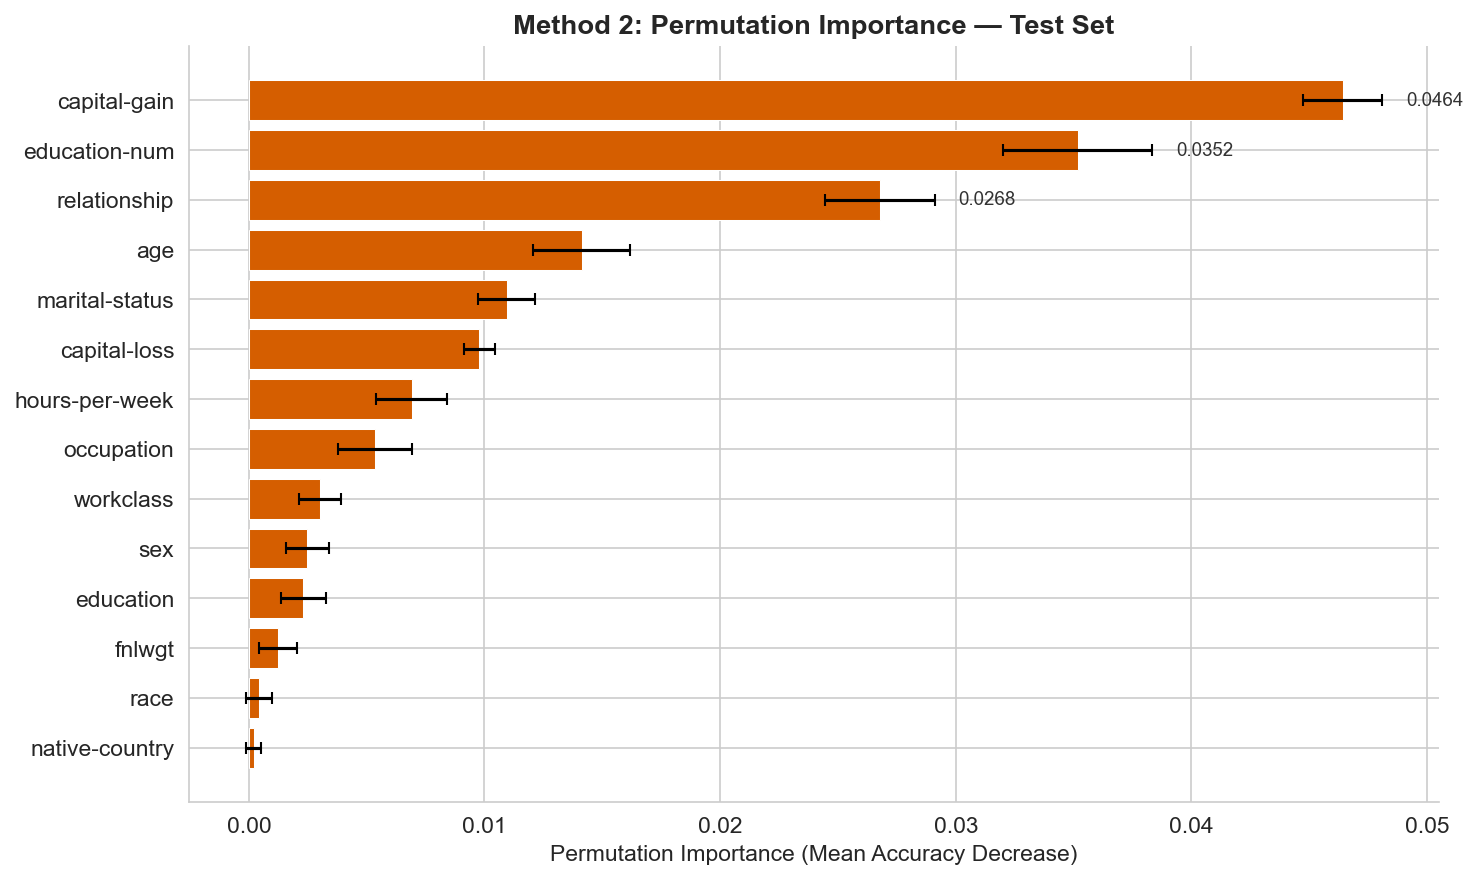

Top 5 features by permutation importance:
  1. capital-gain: 0.0464 ± 0.0017
  2. education-num: 0.0352 ± 0.0032
  3. relationship: 0.0268 ± 0.0023
  4. age: 0.0141 ± 0.0021
  5. marital-status: 0.0109 ± 0.0012


In [7]:
# Method 2: Permutation importance (on test set)
print("Computing permutation importance (10 repeats)...")
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=SEED, n_jobs=-1
)

perm_imp = perm_result.importances_mean
perm_std = perm_result.importances_std
perm_order = np.argsort(perm_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
sorted_perm = perm_imp[perm_order]
sorted_perm_std = perm_std[perm_order]
sorted_perm_names = feature_names_arr[perm_order].tolist()

ax.barh(y_pos, sorted_perm, xerr=sorted_perm_std, color=CB_PALETTE[1],
        edgecolor='white', linewidth=0.5, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_perm_names)
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (Mean Accuracy Decrease)')
ax.set_title('Method 2: Permutation Importance — Test Set', fontweight='bold')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for i in range(3):
    ax.text(sorted_perm[i] + sorted_perm_std[i] + 0.001, i,
            f'{sorted_perm[i]:.4f}', va='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/permutation_importance.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Top 5 features by permutation importance:")
for i in range(5):
    print(f"  {i+1}. {sorted_perm_names[i]}: {sorted_perm[i]:.4f} ± {sorted_perm_std[i]:.4f}")

## 5. Method 3: SHAP Values

**SHAP** (SHapley Additive exPlanations) is based on Shapley values from cooperative game theory. The core idea: treat each feature as a "player" in a game where the "payout" is the model's prediction. SHAP calculates how much each feature contributes to moving the prediction away from the average.

**What makes SHAP special:**
- **Local explanations:** SHAP explains individual predictions, not just global importance
- **Additive:** The SHAP values for all features sum exactly to the difference between the prediction and the average prediction
- **Theoretically grounded:** SHAP is the only method that satisfies all three desirable properties: local accuracy, missingness, and consistency (Lundberg & Lee, 2017)
- **Directional:** SHAP tells you not just *how much* a feature matters, but *whether* it pushes the prediction up or down

For tree-based models, `TreeExplainer` computes exact SHAP values efficiently in polynomial time.

In [8]:
# Method 3: SHAP values using TreeExplainer
print("Computing SHAP values (this may take a minute)...")

# Use a subsample for speed
sample_size = 2000
X_test_sample = X_test[:sample_size]

explainer = shap.TreeExplainer(rf)
shap_values_raw = explainer.shap_values(X_test_sample)

# Handle different SHAP output formats for binary classification
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]  # positive class
    shap_vals_all = shap_values_raw
elif shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]  # positive class
    shap_vals_all = [shap_values_raw[:, :, 0], shap_values_raw[:, :, 1]]
else:
    shap_vals = shap_values_raw
    shap_vals_all = shap_values_raw

print(f"SHAP values shape: {shap_vals.shape}")
print("SHAP computation complete.")


Computing SHAP values (this may take a minute)...


SHAP values shape: (2000, 14)
SHAP computation complete.


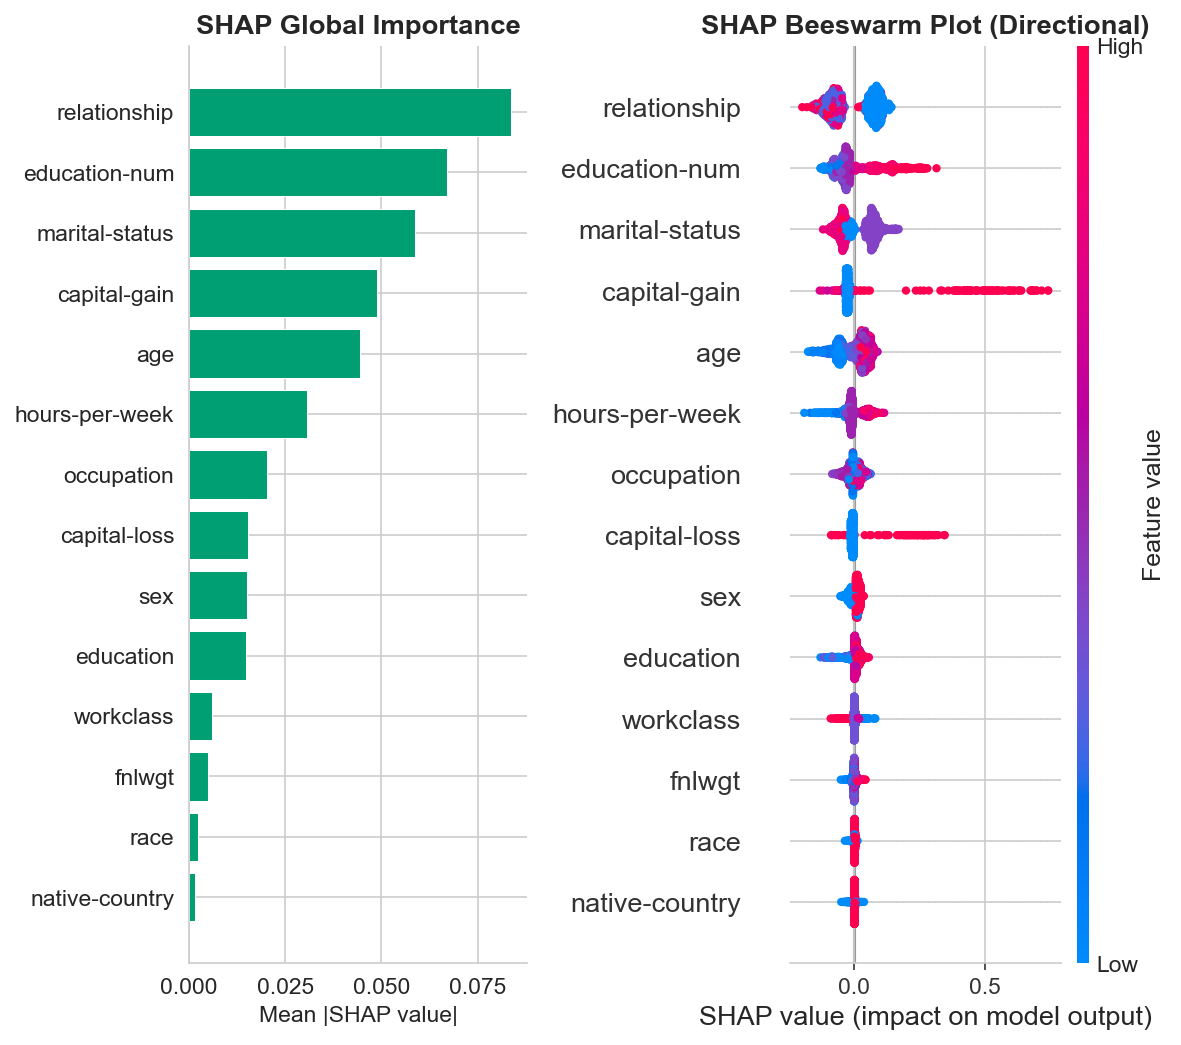

Top 5 features by mean |SHAP|:
  1. relationship: 0.0837
  2. education-num: 0.0671
  3. marital-status: 0.0586
  4. capital-gain: 0.0489
  5. age: 0.0444


In [9]:
# SHAP Summary Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Bar plot (global importance)
shap_mean_abs = np.abs(shap_vals).mean(axis=0)
shap_order = np.argsort(shap_mean_abs)[::-1]
sorted_shap = shap_mean_abs[shap_order]
sorted_shap_names = feature_names_arr[shap_order].tolist()

axes[0].barh(np.arange(len(feature_names)), sorted_shap, color=CB_PALETTE[2],
             edgecolor='white', linewidth=0.5)
axes[0].set_yticks(np.arange(len(feature_names)))
axes[0].set_yticklabels(sorted_shap_names)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('SHAP Global Importance', fontweight='bold')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right: Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_test_sample, feature_names=feature_names,
                  show=False, max_display=14)
axes[1].set_title('SHAP Beeswarm Plot (Directional)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/shap_summary.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Top 5 features by mean |SHAP|:")
for i in range(5):
    print(f"  {i+1}. {sorted_shap_names[i]}: {sorted_shap[i]:.4f}")


### Reading the SHAP Beeswarm Plot

The beeswarm plot above is one of the most information-dense visualisations in machine learning. Here's how to read it:

- **Y-axis:** Features ranked by importance (most important at top)
- **X-axis:** SHAP value — how much that feature pushes the prediction away from the baseline
- **Each dot:** One data point (one person in our dataset)
- **Colour:** The actual feature value (red = high, blue = low)

**Example interpretation:** If `capital-gain` shows red dots clustered to the right, it means *high capital gains push the prediction toward >50K income*. Blue dots on the left mean *low capital gains push toward ≤50K*. This directional information is something neither Gini nor permutation importance provides.

## 6. Head-to-Head: Comparing All Three Methods

Now for the key question: **do these methods agree?** Let's create a unified comparison.

In [10]:
# Create ranking comparison
rankings = pd.DataFrame({
    'Feature': feature_names,
    'Gini_Imp': gini_imp,
    'Perm_Imp': perm_imp,
    'SHAP_Imp': shap_mean_abs
})

# Add ranks (1 = most important)
rankings['Gini_Rank'] = rankings['Gini_Imp'].rank(ascending=False).astype(int)
rankings['Perm_Rank'] = rankings['Perm_Imp'].rank(ascending=False).astype(int)
rankings['SHAP_Rank'] = rankings['SHAP_Imp'].rank(ascending=False).astype(int)

# Rank disagreement
rankings['Max_Rank_Diff'] = rankings[['Gini_Rank','Perm_Rank','SHAP_Rank']].apply(
    lambda r: r.max() - r.min(), axis=1)

print("Feature Rankings Comparison:")
print("=" * 70)
display_cols = ['Feature','Gini_Rank','Perm_Rank','SHAP_Rank','Max_Rank_Diff']
print(rankings[display_cols].sort_values('SHAP_Rank').to_string(index=False))

# Rank correlation
from scipy.stats import spearmanr
corr_gp, _ = spearmanr(rankings['Gini_Rank'], rankings['Perm_Rank'])
corr_gs, _ = spearmanr(rankings['Gini_Rank'], rankings['SHAP_Rank'])
corr_ps, _ = spearmanr(rankings['Perm_Rank'], rankings['SHAP_Rank'])
print(f"\nSpearman Rank Correlations:")
print(f"  Gini vs Permutation: {corr_gp:.3f}")
print(f"  Gini vs SHAP:       {corr_gs:.3f}")
print(f"  Permutation vs SHAP: {corr_ps:.3f}")

Feature Rankings Comparison:
       Feature  Gini_Rank  Perm_Rank  SHAP_Rank  Max_Rank_Diff
  relationship          2          3          1              2
 education-num          3          2          2              1
marital-status          4          5          3              2
  capital-gain          1          1          4              3
           age          5          4          5              1
hours-per-week          6          7          6              1
    occupation          8          8          7              1
  capital-loss          7          6          8              2
           sex         11         10          9              2
     education          9         11         10              2
     workclass         12          9         11              3
        fnlwgt         10         12         12              2
          race         14         13         13              1
native-country         13         14         14              1

Spearman Rank Correlation

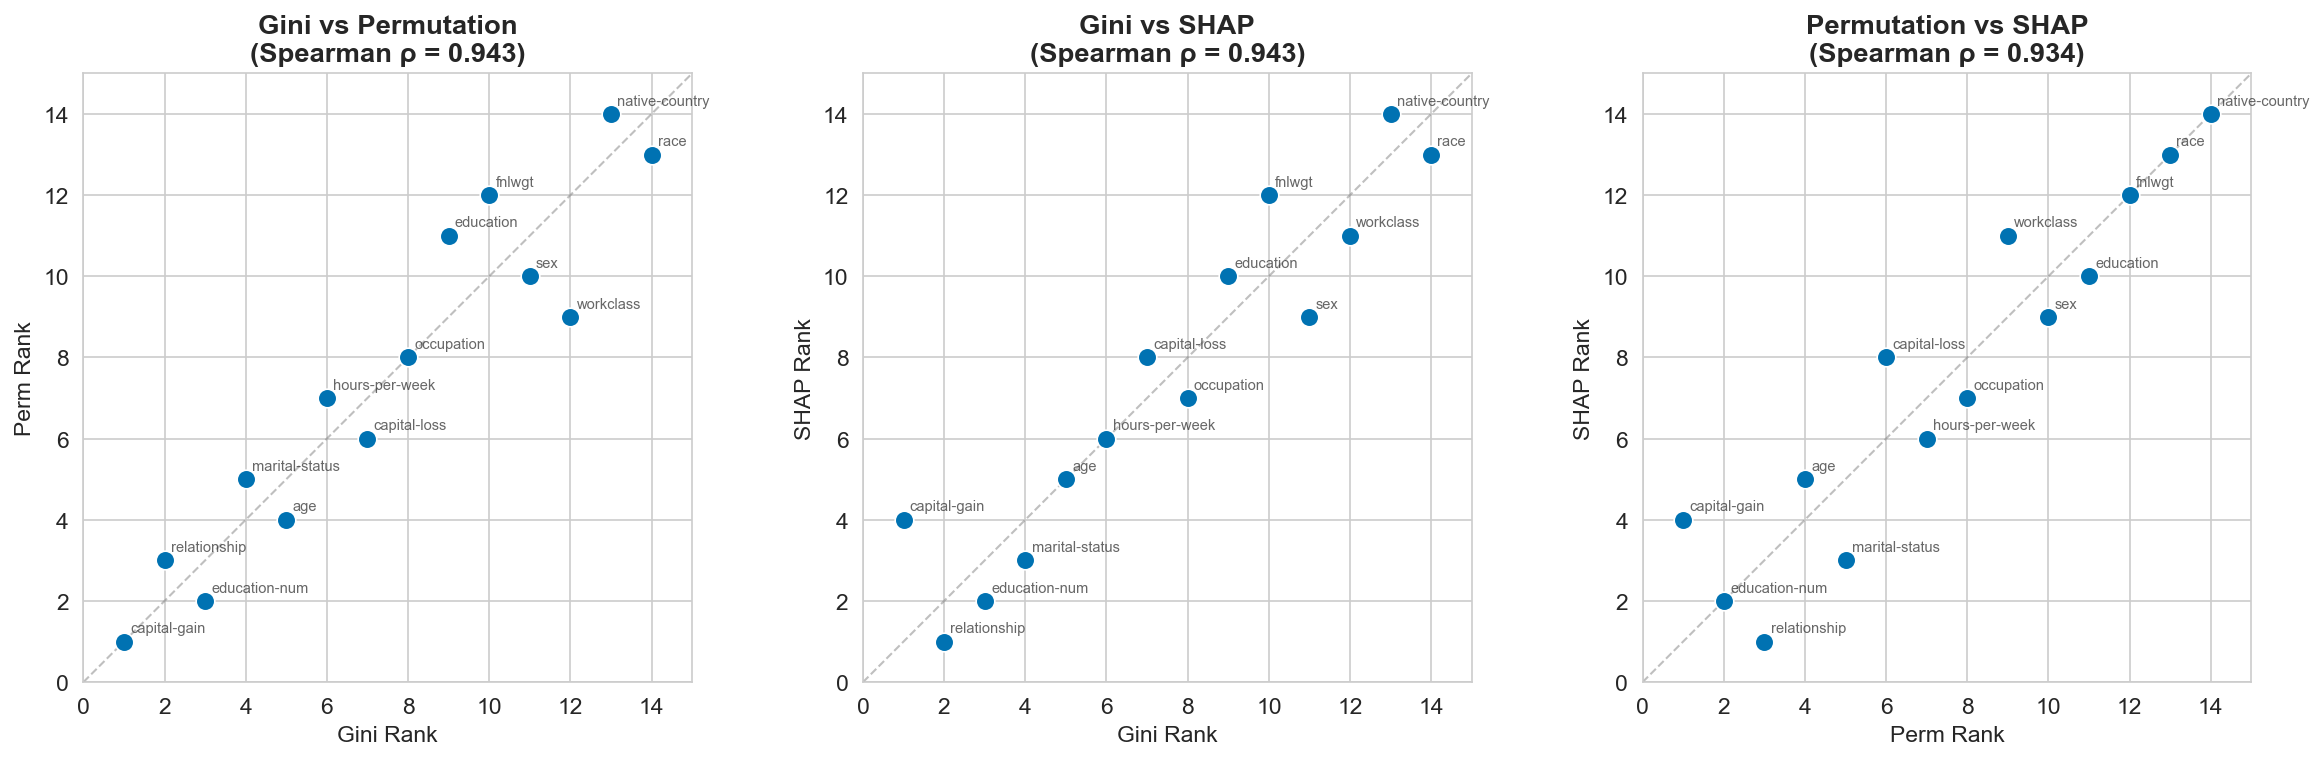

In [11]:
# Visualise ranking comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

method_pairs = [
    ('Gini_Rank', 'Perm_Rank', 'Gini vs Permutation', corr_gp),
    ('Gini_Rank', 'SHAP_Rank', 'Gini vs SHAP', corr_gs),
    ('Perm_Rank', 'SHAP_Rank', 'Permutation vs SHAP', corr_ps),
]

for ax, (m1, m2, title, corr) in zip(axes, method_pairs):
    ax.scatter(rankings[m1], rankings[m2], c=CB_PALETTE[0], s=80,
               edgecolors='white', linewidth=0.8, zorder=3)
    
    # Label each point
    for _, row in rankings.iterrows():
        ax.annotate(row['Feature'], (row[m1], row[m2]),
                    fontsize=7, ha='left', va='bottom', alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')
    
    # Perfect agreement line
    lims = [0, len(feature_names) + 1]
    ax.plot(lims, lims, '--', color='gray', alpha=0.5, linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(m1.replace('_', ' '))
    ax.set_ylabel(m2.replace('_', ' '))
    ax.set_title(f'{title}\n(Spearman ρ = {corr:.3f})', fontweight='bold')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ranking_comparison.png', bbox_inches='tight', facecolor='white')
plt.show()

### Where Do the Methods Disagree — and Why?

Look at the ranking comparison table above. You'll likely notice:

1. **Top features largely agree:** The most important features (e.g., `relationship`, `age`, `capital-gain`) tend to rank high across all three methods. When a feature is genuinely strong, all methods detect it.

2. **Mid-ranked features diverge:** Features like `education-num` vs `education`, or `workclass` vs `native-country`, may rank very differently. This happens because:
   - **Gini overvalues high-cardinality categoricals** like `native-country` (41 categories) and `occupation` (14 categories)
   - **Permutation importance can undervalue correlated features** — if `education` and `education-num` are correlated, shuffling one doesn't hurt because the other compensates
   - **SHAP distributes credit more fairly** among correlated features thanks to the Shapley value framework

3. **The Spearman correlations quantify agreement:** A correlation of 1.0 means perfect agreement; lower values indicate systematic disagreements in ranking.

SHAP dependence plot for top feature: relationship


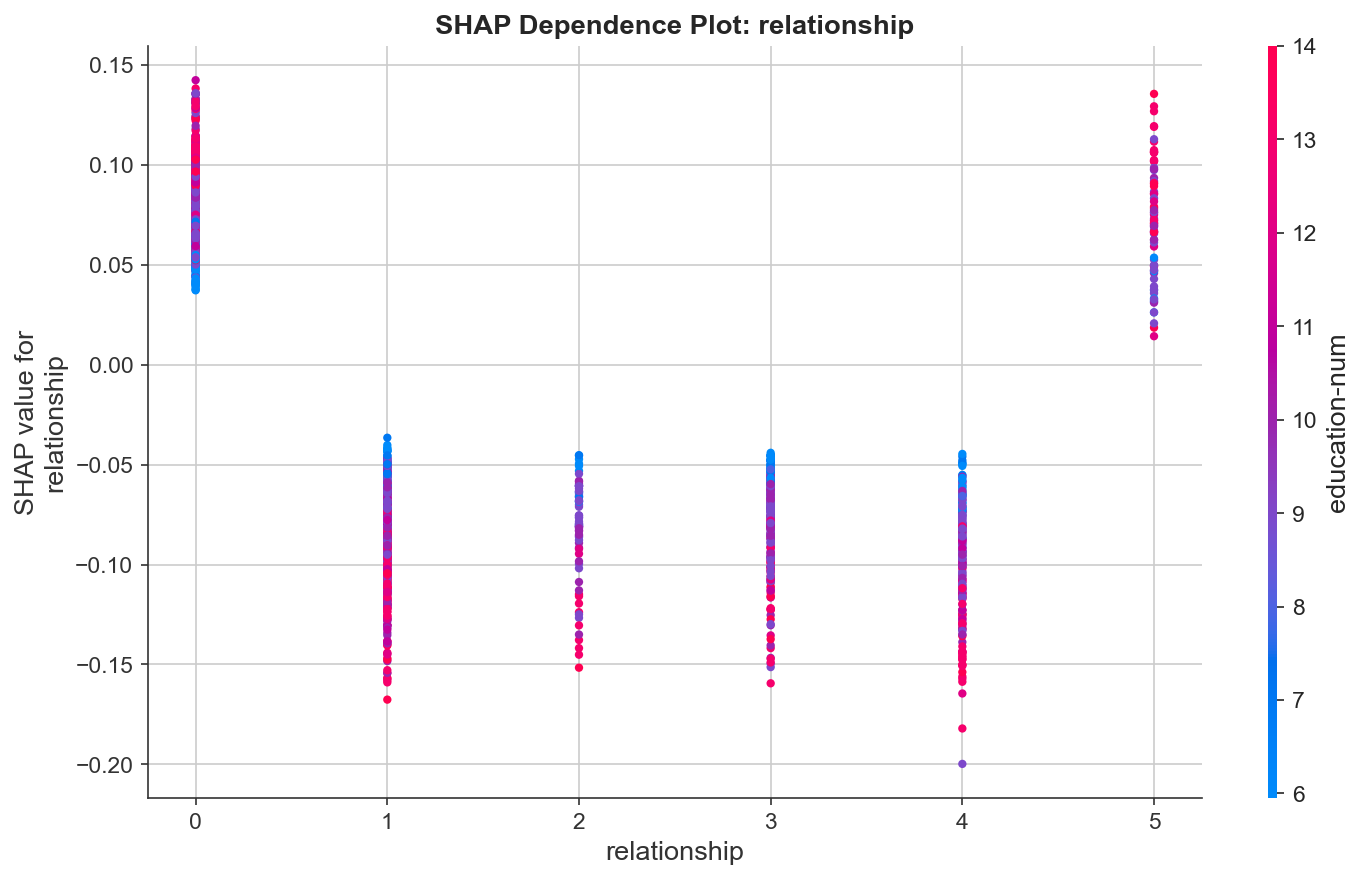

In [12]:
# SHAP Dependence Plot — shows how a feature's value affects prediction
top_feature_idx = shap_order[0]
top_feature_name = feature_names_arr[top_feature_idx]
print(f"SHAP dependence plot for top feature: {top_feature_name}")

fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx, shap_vals, X_test_sample,
    feature_names=feature_names, ax=ax, show=False
)
ax.set_title(f'SHAP Dependence Plot: {top_feature_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/shap_dependence.png', bbox_inches='tight', facecolor='white')
plt.show()


### Reading the SHAP Dependence Plot

The dependence plot shows:
- **X-axis:** The actual feature value
- **Y-axis:** The SHAP value (contribution to prediction)
- **Colour:** An automatically chosen interacting feature

This reveals **non-linear relationships** and **feature interactions** — information that neither Gini nor permutation importance provides. For example, you might see that age has a strong positive effect on income prediction only after age 35, or that capital-gain has a threshold effect.

## 7. Practical Guide: Which Method Should You Use?

| Scenario | Recommended Method | Reason |
|----------|-------------------|--------|
| Quick screening during model development | **Gini importance** | Instant, no extra computation |
| Reporting feature importance to stakeholders | **Permutation importance** | Model-agnostic, easy to explain |
| Detailed model explanation / audit | **SHAP** | Directional, local + global, theoretically sound |
| Features are highly correlated | **SHAP** | Handles correlated features more fairly |
| Very large dataset, limited compute | **Gini importance** | No additional passes over data |
| Regulatory / fairness review | **SHAP** | Can explain individual predictions |

**General advice:** Use Gini importance for exploration, permutation importance for validation, and SHAP when you need to *explain* your model to others.

## 8. Limitations

- **Single model type:** We only tested Random Forest. Results may differ for gradient boosting or linear models
- **Single dataset:** The Adult Income dataset has known issues (outdated, US-centric, class imbalance)
- **Label encoding:** We used LabelEncoder for categoricals, which imposes an arbitrary ordinal relationship. One-hot encoding might change Gini importance rankings
- **SHAP subsample:** We used 2,000 test samples for SHAP computation — results on the full set may vary slightly
- **Correlated features:** The dataset has correlated features (education and education-num), which affects all three methods differently

## 9. Ethical Considerations

The Adult Income dataset contains sensitive attributes including **race, sex, and native-country**. Using these as predictive features raises serious fairness concerns:

- A model that relies heavily on `race` or `sex` may perpetuate historical discrimination
- Feature importance analysis is a **tool for fairness auditing** — if protected attributes rank high, investigate why
- SHAP's ability to show *how* these features influence individual predictions makes it particularly useful for bias detection
- In regulated industries (lending, hiring), explainability is often legally required (e.g., EU's GDPR right to explanation)

## Accessibility Statement

This tutorial uses several accessibility features:
- **Colour-blind friendly palette:** All plots use the Okabe-Ito palette (#0072B2, #D55E00, #009E73)
- **Descriptive titles:** Every figure has a clear, descriptive title
- **Text alternatives:** Key results are printed as text alongside visualisations
- **High contrast:** Figures use white backgrounds with dark text
- **SHAP plots:** The built-in SHAP colour maps are red-blue, which is distinguishable for most colour vision deficiencies

## References

1. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5-32.
2. Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS 2017*.
3. Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures. *BMC Bioinformatics*, 8(25).
4. Molnar, C. (2022). *Interpretable Machine Learning*. 2nd Edition.
5. Scikit-learn: [permutation_importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
6. SHAP documentation: [https://shap.readthedocs.io/](https://shap.readthedocs.io/)